In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os

# change this to your AffectNet dataset root after adding it
root = "/kaggle/input"

for dirname, dirnames, filenames in os.walk(root):
    print("Folder:", dirname)
    print("Subfolders:", dirnames[:10])
    print("Files:", filenames[:10])
    print("-" * 80)

Folder: /kaggle/input
Subfolders: ['datasets']
Files: []
--------------------------------------------------------------------------------
Folder: /kaggle/input/datasets
Subfolders: ['mstjebashazida']
Files: []
--------------------------------------------------------------------------------
Folder: /kaggle/input/datasets/mstjebashazida
Subfolders: ['affectnet']
Files: []
--------------------------------------------------------------------------------
Folder: /kaggle/input/datasets/mstjebashazida/affectnet
Subfolders: ['archive (3)']
Files: []
--------------------------------------------------------------------------------
Folder: /kaggle/input/datasets/mstjebashazida/affectnet/archive (3)
Subfolders: ['Test', 'Train']
Files: ['labels.csv']
--------------------------------------------------------------------------------
Folder: /kaggle/input/datasets/mstjebashazida/affectnet/archive (3)/Test
Subfolders: ['surprise', 'fear', 'neutral', 'sad', 'disgust', 'Contempt', 'happy', 'Anger']
Files

In [2]:
import os
import pandas as pd

# =========================
# AffectNet root folders
# =========================
train_root = "/kaggle/input/datasets/mstjebashazida/affectnet/archive (3)/Train"
test_root  = "/kaggle/input/datasets/mstjebashazida/affectnet/archive (3)/Test"

# =========================
# Unified class list
# IMPORTANT:
# Train uses lowercase names, Test has 'Anger' and 'Contempt'
# We map them to a single canonical order
# =========================
class_names = ["anger", "contempt", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
label_map = {cls_name: idx for idx, cls_name in enumerate(class_names)}

# folder name mapping for Train and Test
train_folder_map = {
    "anger": "anger",
    "contempt": "contempt",
    "disgust": "disgust",
    "fear": "fear",
    "happy": "happy",
    "neutral": "neutral",
    "sad": "sad",
    "surprise": "surprise"
}

test_folder_map = {
    "anger": "Anger",
    "contempt": "Contempt",
    "disgust": "disgust",
    "fear": "fear",
    "happy": "happy",
    "neutral": "neutral",
    "sad": "sad",
    "surprise": "surprise"
}

all_data = []

# =========================
# Collect Train images
# =========================
for cls_name in class_names:
    folder_name = train_folder_map[cls_name]
    class_path = os.path.join(train_root, folder_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        all_data.append([img_path, label_map[cls_name]])

# =========================
# Collect Test images
# =========================
for cls_name in class_names:
    folder_name = test_folder_map[cls_name]
    class_path = os.path.join(test_root, folder_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        all_data.append([img_path, label_map[cls_name]])

# =========================
# Create dataframe
# =========================
df_affect = pd.DataFrame(all_data, columns=["image_path", "label"])

print("Total images in full AffectNet:", len(df_affect))
print("\nClass distribution:")
print(df_affect["label"].value_counts().sort_index())

print("\nFirst 5 rows:")
print(df_affect.head())

Total images in full AffectNet: 30626

Class distribution:
label
0    3218
1    2871
2    2477
3    3176
4    5044
5    5126
6    4675
7    4039
Name: count, dtype: int64

First 5 rows:
                                          image_path  label
0  /kaggle/input/datasets/mstjebashazida/affectne...      0
1  /kaggle/input/datasets/mstjebashazida/affectne...      0
2  /kaggle/input/datasets/mstjebashazida/affectne...      0
3  /kaggle/input/datasets/mstjebashazida/affectne...      0
4  /kaggle/input/datasets/mstjebashazida/affectne...      0


In [3]:
from sklearn.model_selection import train_test_split

# =========================
# 80:20 stratified split
# =========================
train_df_affect, test_df_affect = train_test_split(
    df_affect,
    test_size=0.20,
    stratify=df_affect["label"],
    random_state=42
)

train_df_affect = train_df_affect.reset_index(drop=True)
test_df_affect  = test_df_affect.reset_index(drop=True)

print("AffectNet 80:20 Train size:", len(train_df_affect))
print("AffectNet 80:20 Test size :", len(test_df_affect))

print("\nTrain class distribution:")
print(train_df_affect["label"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df_affect["label"].value_counts().sort_index())

AffectNet 80:20 Train size: 24500
AffectNet 80:20 Test size : 6126

Train class distribution:
label
0    2574
1    2297
2    1981
3    2541
4    4035
5    4101
6    3740
7    3231
Name: count, dtype: int64

Test class distribution:
label
0     644
1     574
2     496
3     635
4    1009
5    1025
6     935
7     808
Name: count, dtype: int64


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# =========================
# CNN transforms for AffectNet
# =========================
cnn_train_transform_affect = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, shear=10, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

cnn_test_transform_affect = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

# =========================
# AffectNet Dataset class
# =========================
class AffectNetDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = int(self.df.loc[idx, "label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================
# CNN train/test datasets
# =========================
cnn_train_dataset_affect = AffectNetDataset(train_df_affect, transform=cnn_train_transform_affect)
cnn_test_dataset_affect  = AffectNetDataset(test_df_affect, transform=cnn_test_transform_affect)

# =========================
# CNN dataloaders
# =========================
cnn_train_loader_affect = DataLoader(
    cnn_train_dataset_affect,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

cnn_test_loader_affect = DataLoader(
    cnn_test_dataset_affect,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# =========================
# Device + quick check
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("CNN AffectNet Train samples:", len(cnn_train_dataset_affect))
print("CNN AffectNet Test samples :", len(cnn_test_dataset_affect))

Device: cuda
CNN AffectNet Train samples: 24500
CNN AffectNet Test samples : 6126


In [5]:
import torch
import torch.nn as nn

# =========================
# Custom CNN for AffectNet
# =========================
class CustomCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),   # 96x96 -> 48 -> 24 -> 12
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x

# =========================
# Create model
# =========================
cnn_model_affect = CustomCNN(num_classes=8).to(device)

print(cnn_model_affect)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

# =========================
# Loss, optimizer, scheduler
# =========================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    cnn_model_affect.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=80
)

# =========================
# Early Stopping class
# =========================
class EarlyStopping:
    def __init__(self, patience=8):
        self.patience = patience
        self.best_score = None
        self.counter = 0
        self.stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

# =========================
# Training settings
# =========================
epochs = 80
early_stopping = EarlyStopping(patience=8)

train_acc_list_affect = []
test_acc_list_affect = []
train_loss_list_affect = []
test_loss_list_affect = []

best_test_acc_affect = 0

# =========================
# Training loop
# =========================
for epoch in range(epochs):

    # ---------- TRAIN ----------
    cnn_model_affect.train()
    running_train_loss = 0
    correct = 0
    total = 0

    for images, labels in cnn_train_loader_affect:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = cnn_model_affect(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_train_loss / len(cnn_train_loader_affect)

    # ---------- TEST ----------
    cnn_model_affect.eval()
    running_test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in cnn_test_loader_affect:
            images = images.to(device)
            labels = labels.to(device)

            outputs = cnn_model_affect(images)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    test_acc = 100 * correct / total
    test_loss = running_test_loss / len(cnn_test_loader_affect)

    scheduler.step()

    # save best model
    if test_acc > best_test_acc_affect:
        best_test_acc_affect = test_acc
        torch.save(cnn_model_affect.state_dict(), "/kaggle/working/best_cnn_affectnet_80_20.pth")

    train_acc_list_affect.append(train_acc)
    test_acc_list_affect.append(test_acc)
    train_loss_list_affect.append(train_loss)
    test_loss_list_affect.append(test_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}\n")

    # ---------- Early stopping ----------
    early_stopping(test_acc)
    if early_stopping.stop:
        print("Early stopping triggered")
        break

print("Best CNN AffectNet Test Accuracy:", best_test_acc_affect)
print("Saved model: /kaggle/working/best_cnn_affectnet_80_20.pth")

Epoch 1/80
Train Acc: 22.44 | Test Acc: 31.34
Train Loss: 1.9990 | Test Loss: 1.7670

Epoch 2/80
Train Acc: 25.31 | Test Acc: 31.16
Train Loss: 1.8941 | Test Loss: 1.7475

Epoch 3/80
Train Acc: 25.57 | Test Acc: 31.13
Train Loss: 1.8866 | Test Loss: 1.7341

Epoch 4/80
Train Acc: 26.02 | Test Acc: 32.78
Train Loss: 1.8818 | Test Loss: 1.7321

Epoch 5/80
Train Acc: 25.81 | Test Acc: 33.97
Train Loss: 1.8856 | Test Loss: 1.7281

Epoch 6/80
Train Acc: 26.24 | Test Acc: 32.21
Train Loss: 1.8793 | Test Loss: 1.7336

Epoch 7/80
Train Acc: 26.38 | Test Acc: 31.96
Train Loss: 1.8810 | Test Loss: 1.7365

Epoch 8/80
Train Acc: 26.20 | Test Acc: 35.49
Train Loss: 1.8745 | Test Loss: 1.7259

Epoch 9/80
Train Acc: 26.26 | Test Acc: 31.49
Train Loss: 1.8734 | Test Loss: 1.6777

Epoch 10/80
Train Acc: 26.34 | Test Acc: 37.56
Train Loss: 1.8553 | Test Loss: 1.7081

Epoch 11/80
Train Acc: 27.47 | Test Acc: 32.11
Train Loss: 1.8341 | Test Loss: 1.6676

Epoch 12/80
Train Acc: 30.56 | Test Acc: 34.74
Train

In [7]:
import torch
import torch.nn.functional as F
import numpy as np

# =========================
# Load best saved CNN model
# =========================
cnn_model_affect.load_state_dict(torch.load("/kaggle/working/best_cnn_affectnet_80_20.pth"))
cnn_model_affect.eval()

cnn_probs_affect = []
cnn_preds_affect = []
y_true_affect = []

# =========================
# Get probabilities on test set
# =========================
with torch.no_grad():
    for images, labels in cnn_test_loader_affect:
        images = images.to(device)
        labels = labels.to(device)

        outputs = cnn_model_affect(images)
        probs = F.softmax(outputs, dim=1)

        cnn_probs_affect.extend(probs.cpu().numpy())
        cnn_preds_affect.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_true_affect.extend(labels.cpu().numpy())

cnn_probs_affect = np.array(cnn_probs_affect)
cnn_preds_affect = np.array(cnn_preds_affect)
y_true_affect = np.array(y_true_affect)

print("CNN AffectNet probabilities shape :", cnn_probs_affect.shape)
print("CNN AffectNet predictions shape   :", cnn_preds_affect.shape)
print("CNN AffectNet true labels shape   :", y_true_affect.shape)

cnn_acc_affect = (cnn_preds_affect == y_true_affect).mean() * 100
print(f"\nCNN AffectNet Accuracy from saved model: {cnn_acc_affect:.2f}%")

CNN AffectNet probabilities shape : (6126, 8)
CNN AffectNet predictions shape   : (6126,)
CNN AffectNet true labels shape   : (6126,)

CNN AffectNet Accuracy from saved model: 72.10%


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# =========================
# ResNet transforms for AffectNet
# =========================
resnet_train_transform_affect = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

resnet_test_transform_affect = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

# =========================
# AffectNet Dataset class for ResNet
# =========================
class AffectNetDatasetResNet(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = int(self.df.loc[idx, "label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================
# ResNet train/test datasets
# =========================
resnet_train_dataset_affect = AffectNetDatasetResNet(
    train_df_affect, transform=resnet_train_transform_affect
)

resnet_test_dataset_affect = AffectNetDatasetResNet(
    test_df_affect, transform=resnet_test_transform_affect
)

# =========================
# ResNet dataloaders
# =========================
resnet_train_loader_affect = DataLoader(
    resnet_train_dataset_affect,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

resnet_test_loader_affect = DataLoader(
    resnet_test_dataset_affect,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("ResNet AffectNet Train samples:", len(resnet_train_dataset_affect))
print("ResNet AffectNet Test samples :", len(resnet_test_dataset_affect))

ResNet AffectNet Train samples: 24500
ResNet AffectNet Test samples : 6126


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
# ResNet50 Bottleneck block
# =========================
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super(Bottleneck, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion,
                               kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

# =========================
# ResNet50 Scratch
# =========================
class ResNet50Scratch(nn.Module):
    def __init__(self, num_classes=8):
        super(ResNet50Scratch, self).__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2,
                               padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 3, stride=1)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512 * Bottleneck.expansion, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        layers = []
        layers.append(Bottleneck(self.in_channels, out_channels, stride))
        self.in_channels = out_channels * Bottleneck.expansion

        for _ in range(1, blocks):
            layers.append(Bottleneck(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# =========================
# Create model
# =========================
resnet_model_affect = ResNet50Scratch(num_classes=8).to(device)

print(resnet_model_affect)

ResNet50Scratch(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

# =========================
# Loss, optimizer, scheduler
# =========================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    resnet_model_affect.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

# =========================
# Early Stopping class
# =========================
class EarlyStopping:
    def __init__(self, patience=8):
        self.patience = patience
        self.best_score = None
        self.counter = 0
        self.stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

# =========================
# Training settings
# =========================
epochs = 50
early_stopping = EarlyStopping(patience=8)

train_acc_list_resnet_affect = []
test_acc_list_resnet_affect = []
train_loss_list_resnet_affect = []
test_loss_list_resnet_affect = []

best_test_acc_resnet_affect = 0

# =========================
# Training loop
# =========================
for epoch in range(epochs):

    # ---------- TRAIN ----------
    resnet_model_affect.train()
    running_train_loss = 0
    correct = 0
    total = 0

    for images, labels in resnet_train_loader_affect:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = resnet_model_affect(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_train_loss / len(resnet_train_loader_affect)

    # ---------- TEST ----------
    resnet_model_affect.eval()
    running_test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in resnet_test_loader_affect:
            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet_model_affect(images)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    test_acc = 100 * correct / total
    test_loss = running_test_loss / len(resnet_test_loader_affect)

    scheduler.step()

    # save best model
    if test_acc > best_test_acc_resnet_affect:
        best_test_acc_resnet_affect = test_acc
        torch.save(
            resnet_model_affect.state_dict(),
            "/kaggle/working/best_resnet50_affectnet_80_20.pth"
        )

    train_acc_list_resnet_affect.append(train_acc)
    test_acc_list_resnet_affect.append(test_acc)
    train_loss_list_resnet_affect.append(train_loss)
    test_loss_list_resnet_affect.append(test_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}\n")

    # ---------- Early stopping ----------
    early_stopping(test_acc)
    if early_stopping.stop:
        print("Early stopping triggered")
        break

print("Best ResNet50 AffectNet Test Accuracy:", best_test_acc_resnet_affect)
print("Saved model: /kaggle/working/best_resnet50_affectnet_80_20.pth")

Epoch 1/50
Train Acc: 33.66 | Test Acc: 42.39
Train Loss: 1.8090 | Test Loss: 1.5870

Epoch 2/50
Train Acc: 46.55 | Test Acc: 49.23
Train Loss: 1.5324 | Test Loss: 1.4586

Epoch 3/50
Train Acc: 53.22 | Test Acc: 57.62
Train Loss: 1.4025 | Test Loss: 1.3241

Epoch 4/50
Train Acc: 56.57 | Test Acc: 57.90
Train Loss: 1.3434 | Test Loss: 1.3361

Epoch 5/50
Train Acc: 58.49 | Test Acc: 59.55
Train Loss: 1.3089 | Test Loss: 1.3216

Epoch 6/50
Train Acc: 60.65 | Test Acc: 62.36
Train Loss: 1.2775 | Test Loss: 1.2502

Epoch 7/50
Train Acc: 61.21 | Test Acc: 54.62
Train Loss: 1.2590 | Test Loss: 1.4212

Epoch 8/50
Train Acc: 61.62 | Test Acc: 62.63
Train Loss: 1.2469 | Test Loss: 1.2426

Epoch 9/50
Train Acc: 63.42 | Test Acc: 63.81
Train Loss: 1.2235 | Test Loss: 1.2104

Epoch 10/50
Train Acc: 63.93 | Test Acc: 64.82
Train Loss: 1.2073 | Test Loss: 1.1994

Epoch 11/50
Train Acc: 64.73 | Test Acc: 64.32
Train Loss: 1.1866 | Test Loss: 1.1947

Epoch 12/50
Train Acc: 65.56 | Test Acc: 66.01
Train

In [11]:
import torch
import torch.nn.functional as F
import numpy as np

# =========================
# Load best saved ResNet50 model
# =========================
resnet_model_affect.load_state_dict(
    torch.load("/kaggle/working/best_resnet50_affectnet_80_20.pth")
)
resnet_model_affect.eval()

resnet_probs_affect = []
resnet_preds_affect = []

# y_true_affect already exists from CNN test extraction
# but if you want, we can also collect it again here

with torch.no_grad():
    for images, labels in resnet_test_loader_affect:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model_affect(images)
        probs = F.softmax(outputs, dim=1)

        resnet_probs_affect.extend(probs.cpu().numpy())
        resnet_preds_affect.extend(torch.argmax(probs, dim=1).cpu().numpy())

resnet_probs_affect = np.array(resnet_probs_affect)
resnet_preds_affect = np.array(resnet_preds_affect)

print("ResNet50 AffectNet probabilities shape :", resnet_probs_affect.shape)
print("ResNet50 AffectNet predictions shape   :", resnet_preds_affect.shape)
print("AffectNet true labels shape            :", y_true_affect.shape)

resnet_acc_affect = (resnet_preds_affect == y_true_affect).mean() * 100
print(f"\nResNet50 AffectNet Accuracy from saved model: {resnet_acc_affect:.2f}%")

ResNet50 AffectNet probabilities shape : (6126, 8)
ResNet50 AffectNet predictions shape   : (6126,)
AffectNet true labels shape            : (6126,)

ResNet50 AffectNet Accuracy from saved model: 72.40%


In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# =========================
# Improved EfficientNet transforms for AffectNet
# =========================
eff_train_transform_affect_v2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08),
        scale=(0.90, 1.10)
    ),
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.25
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eff_test_transform_affect_v2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# =========================
# AffectNet Dataset class
# =========================
class AffectNetDatasetEffV2(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = int(self.df.loc[idx, "label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================
# Improved EfficientNet train/test datasets
# =========================
eff_train_dataset_affect_v2 = AffectNetDatasetEffV2(
    train_df_affect, transform=eff_train_transform_affect_v2
)

eff_test_dataset_affect_v2 = AffectNetDatasetEffV2(
    test_df_affect, transform=eff_test_transform_affect_v2
)

# =========================
# Improved EfficientNet dataloaders
# =========================
eff_train_loader_affect_v2 = DataLoader(
    eff_train_dataset_affect_v2,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

eff_test_loader_affect_v2 = DataLoader(
    eff_test_dataset_affect_v2,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Improved EfficientNet AffectNet Train samples:", len(eff_train_dataset_affect_v2))
print("Improved EfficientNet AffectNet Test samples :", len(eff_test_dataset_affect_v2))

Improved EfficientNet AffectNet Train samples: 24500
Improved EfficientNet AffectNet Test samples : 6126


In [19]:
import torch
import torch.nn as nn
from torchvision import models

# =========================
# Improved EfficientNet-B3 for AffectNet
# =========================
efficientnet_model_affect_v2 = models.efficientnet_b3(weights="IMAGENET1K_V1")

# old classifier input features
in_features = efficientnet_model_affect_v2.classifier[1].in_features

# replace classifier with dropout + linear
efficientnet_model_affect_v2.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 8)
)

efficientnet_model_affect_v2 = efficientnet_model_affect_v2.to(device)

print(efficientnet_model_affect_v2)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim

# =========================
# Loss, optimizer, scheduler
# =========================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    efficientnet_model_affect_v2.parameters(),
    lr=0.0002,
    weight_decay=2e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=60
)

# =========================
# Early Stopping class
# =========================
class EarlyStopping:
    def __init__(self, patience=8):
        self.patience = patience
        self.best_score = None
        self.counter = 0
        self.stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

# =========================
# Training settings
# =========================
epochs = 60
early_stopping = EarlyStopping(patience=8)

train_acc_list_eff_affect_v2 = []
test_acc_list_eff_affect_v2 = []
train_loss_list_eff_affect_v2 = []
test_loss_list_eff_affect_v2 = []

best_test_acc_eff_affect_v2 = 0

# =========================
# Training loop
# =========================
for epoch in range(epochs):

    # ---------- TRAIN ----------
    efficientnet_model_affect_v2.train()
    running_train_loss = 0
    correct = 0
    total = 0

    for images, labels in eff_train_loader_affect_v2:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = efficientnet_model_affect_v2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_train_loss / len(eff_train_loader_affect_v2)

    # ---------- TEST ----------
    efficientnet_model_affect_v2.eval()
    running_test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in eff_test_loader_affect_v2:
            images = images.to(device)
            labels = labels.to(device)

            outputs = efficientnet_model_affect_v2(images)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    test_acc = 100 * correct / total
    test_loss = running_test_loss / len(eff_test_loader_affect_v2)

    scheduler.step()

    # save best model
    if test_acc > best_test_acc_eff_affect_v2:
        best_test_acc_eff_affect_v2 = test_acc
        torch.save(
            efficientnet_model_affect_v2.state_dict(),
            "/kaggle/working/best_efficientnet_affectnet_80_20_v2.pth"
        )

    train_acc_list_eff_affect_v2.append(train_acc)
    test_acc_list_eff_affect_v2.append(test_acc)
    train_loss_list_eff_affect_v2.append(train_loss)
    test_loss_list_eff_affect_v2.append(test_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}\n")

    # ---------- Early stopping ----------
    early_stopping(test_acc)
    if early_stopping.stop:
        print("Early stopping triggered")
        break

print("Best Improved EfficientNet AffectNet Test Accuracy:", best_test_acc_eff_affect_v2)
print("Saved model: /kaggle/working/best_efficientnet_affectnet_80_20_v2.pth")

Epoch 1/60
Train Acc: 57.01 | Test Acc: 69.51
Train Loss: 1.3432 | Test Loss: 1.1106

Epoch 2/60
Train Acc: 69.19 | Test Acc: 71.30
Train Loss: 1.1164 | Test Loss: 1.0684

Epoch 3/60
Train Acc: 72.42 | Test Acc: 73.51
Train Loss: 1.0516 | Test Loss: 1.0355

Epoch 4/60
Train Acc: 75.16 | Test Acc: 74.75
Train Loss: 1.0006 | Test Loss: 1.0154

Epoch 5/60
Train Acc: 77.38 | Test Acc: 73.95
Train Loss: 0.9565 | Test Loss: 1.0356

Epoch 6/60
Train Acc: 78.88 | Test Acc: 73.52
Train Loss: 0.9208 | Test Loss: 1.0434

Epoch 7/60
Train Acc: 81.01 | Test Acc: 73.41
Train Loss: 0.8832 | Test Loss: 1.0436

Epoch 8/60
Train Acc: 82.74 | Test Acc: 74.67
Train Loss: 0.8450 | Test Loss: 1.0507

Epoch 9/60
Train Acc: 84.09 | Test Acc: 74.49
Train Loss: 0.8159 | Test Loss: 1.0553

Epoch 10/60
Train Acc: 85.87 | Test Acc: 74.80
Train Loss: 0.7852 | Test Loss: 1.0587

Epoch 11/60
Train Acc: 86.99 | Test Acc: 74.08
Train Loss: 0.7623 | Test Loss: 1.0943

Epoch 12/60
Train Acc: 87.87 | Test Acc: 74.18
Train

In [21]:
import torch
import torch.nn.functional as F
import numpy as np

# =========================
# Load improved saved EfficientNet model
# =========================
efficientnet_model_affect_v2.load_state_dict(
    torch.load("/kaggle/working/best_efficientnet_affectnet_80_20_v2.pth")
)
efficientnet_model_affect_v2.eval()

eff_probs_affect_v2 = []
eff_preds_affect_v2 = []

with torch.no_grad():
    for images, labels in eff_test_loader_affect_v2:
        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet_model_affect_v2(images)
        probs = F.softmax(outputs, dim=1)

        eff_probs_affect_v2.extend(probs.cpu().numpy())
        eff_preds_affect_v2.extend(torch.argmax(probs, dim=1).cpu().numpy())

eff_probs_affect_v2 = np.array(eff_probs_affect_v2)
eff_preds_affect_v2 = np.array(eff_preds_affect_v2)

print("Improved EfficientNet AffectNet probabilities shape :", eff_probs_affect_v2.shape)
print("Improved EfficientNet AffectNet predictions shape   :", eff_preds_affect_v2.shape)
print("AffectNet true labels shape                         :", y_true_affect.shape)

eff_acc_affect_v2 = (eff_preds_affect_v2 == y_true_affect).mean() * 100
print(f"\nImproved EfficientNet AffectNet Accuracy from saved model: {eff_acc_affect_v2:.2f}%")

Improved EfficientNet AffectNet probabilities shape : (6126, 8)
Improved EfficientNet AffectNet predictions shape   : (6126,)
AffectNet true labels shape                         : (6126,)

Improved EfficientNet AffectNet Accuracy from saved model: 74.80%


In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# =========================================================
# DST helper functions
# =========================================================
def probs_to_mass(prob_vector):
    return prob_vector / np.sum(prob_vector)

def dst_combine_two(m1, m2, eps=1e-12):
    combined = m1 * m2
    s = combined.sum()

    if s < eps:
        combined = (m1 + m2) / 2.0
        combined = combined / combined.sum()
        return combined

    combined = combined / s
    return combined

def fuse_probabilities(prob1, prob2):
    fused_probs = []
    fused_preds = []

    for p1, p2 in zip(prob1, prob2):
        m1 = probs_to_mass(p1)
        m2 = probs_to_mass(p2)

        fused = dst_combine_two(m1, m2)
        fused_probs.append(fused)
        fused_preds.append(np.argmax(fused))

    return np.array(fused_probs), np.array(fused_preds)

def fuse_three_probabilities(prob1, prob2, prob3):
    fused12_probs, _ = fuse_probabilities(prob1, prob2)
    fused123_probs, fused123_preds = fuse_probabilities(fused12_probs, prob3)
    return fused123_probs, fused123_preds

# =========================================================
# Pairwise DST fusion using improved EfficientNet
# =========================================================
cnn_resnet_probs_affect_v2, cnn_resnet_preds_affect_v2 = fuse_probabilities(
    cnn_probs_affect, resnet_probs_affect
)

cnn_eff_probs_affect_v2, cnn_eff_preds_affect_v2 = fuse_probabilities(
    cnn_probs_affect, eff_probs_affect_v2
)

resnet_eff_probs_affect_v2, resnet_eff_preds_affect_v2 = fuse_probabilities(
    resnet_probs_affect, eff_probs_affect_v2
)

# =========================================================
# Triple DST fusion using improved EfficientNet
# =========================================================
cnn_resnet_eff_probs_affect_v2, cnn_resnet_eff_preds_affect_v2 = fuse_three_probabilities(
    cnn_probs_affect, resnet_probs_affect, eff_probs_affect_v2
)

# =========================================================
# Accuracy calculation
# =========================================================
cnn_resnet_acc_affect_v2 = accuracy_score(y_true_affect, cnn_resnet_preds_affect_v2) * 100
cnn_eff_acc_affect_v2 = accuracy_score(y_true_affect, cnn_eff_preds_affect_v2) * 100
resnet_eff_acc_affect_v2 = accuracy_score(y_true_affect, resnet_eff_preds_affect_v2) * 100
cnn_resnet_eff_acc_affect_v2 = accuracy_score(y_true_affect, cnn_resnet_eff_preds_affect_v2) * 100

print(f"CNN + ResNet50 DST Accuracy: {cnn_resnet_acc_affect_v2:.2f}%")
print(f"CNN + Improved EfficientNet DST Accuracy: {cnn_eff_acc_affect_v2:.2f}%")
print(f"ResNet50 + Improved EfficientNet DST Accuracy: {resnet_eff_acc_affect_v2:.2f}%")
print(f"CNN + ResNet50 + Improved EfficientNet DST Accuracy: {cnn_resnet_eff_acc_affect_v2:.2f}%")

# =========================================================
# Final DST results table
# =========================================================
dst_results_affect_v2 = pd.DataFrame({
    "Fusion Pair": [
        "CustomCNN + ResNet50",
        "CustomCNN + Improved EfficientNet",
        "ResNet50 + Improved EfficientNet",
        "CustomCNN + ResNet50 + Improved EfficientNet"
    ],
    "DST Accuracy (%)": [
        cnn_resnet_acc_affect_v2,
        cnn_eff_acc_affect_v2,
        resnet_eff_acc_affect_v2,
        cnn_resnet_eff_acc_affect_v2
    ]
})

dst_results_affect_v2 = dst_results_affect_v2.sort_values(
    by="DST Accuracy (%)", ascending=False
).reset_index(drop=True)

print("\nDST Fusion Results (AffectNet + Improved EfficientNet):")
print(dst_results_affect_v2)

CNN + ResNet50 DST Accuracy: 74.05%
CNN + Improved EfficientNet DST Accuracy: 76.79%
ResNet50 + Improved EfficientNet DST Accuracy: 76.56%
CNN + ResNet50 + Improved EfficientNet DST Accuracy: 76.79%

DST Fusion Results (AffectNet + Improved EfficientNet):
                                    Fusion Pair  DST Accuracy (%)
0             CustomCNN + Improved EfficientNet         76.787463
1  CustomCNN + ResNet50 + Improved EfficientNet         76.787463
2              ResNet50 + Improved EfficientNet         76.558929
3                          CustomCNN + ResNet50         74.045054


In [23]:
import pandas as pd

# =========================================================
# Final comparison table using Improved EfficientNet
# =========================================================
comparison_results_affect_v2 = pd.DataFrame({
    "Model / Fusion": [
        "CustomCNN",
        "ResNet50",
        "Improved EfficientNet",
        "CustomCNN + ResNet50",
        "CustomCNN + Improved EfficientNet",
        "ResNet50 + Improved EfficientNet",
        "CustomCNN + ResNet50 + Improved EfficientNet"
    ],
    "Accuracy (%)": [
        cnn_acc_affect,
        resnet_acc_affect,
        eff_acc_affect_v2,
        cnn_resnet_acc_affect_v2,
        cnn_eff_acc_affect_v2,
        resnet_eff_acc_affect_v2,
        cnn_resnet_eff_acc_affect_v2
    ]
})

comparison_results_affect_v2 = comparison_results_affect_v2.sort_values(
    by="Accuracy (%)", ascending=False
).reset_index(drop=True)

print("Final AffectNet Comparison Results (Improved EfficientNet):")
print(comparison_results_affect_v2)

Final AffectNet Comparison Results (Improved EfficientNet):
                                 Model / Fusion  Accuracy (%)
0             CustomCNN + Improved EfficientNet     76.787463
1  CustomCNN + ResNet50 + Improved EfficientNet     76.787463
2              ResNet50 + Improved EfficientNet     76.558929
3                         Improved EfficientNet     74.795952
4                          CustomCNN + ResNet50     74.045054
5                                      ResNet50     72.396343
6                                     CustomCNN     72.102514


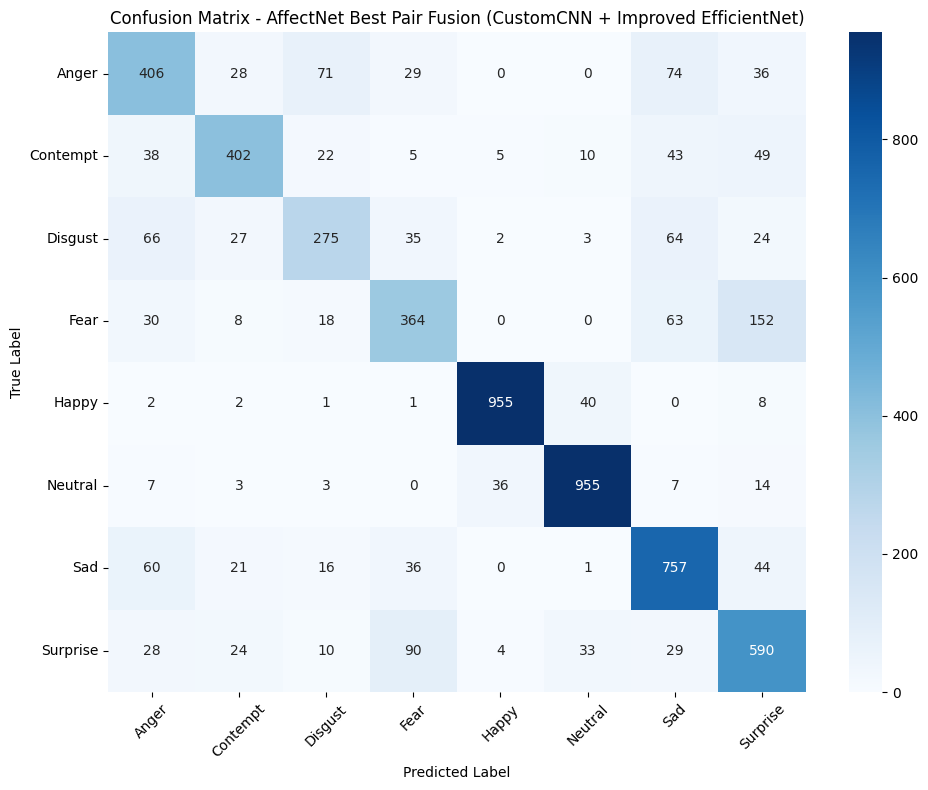

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================
# AffectNet class names
# Make sure this matches your label encoding
# =========================
class_names_affect = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================
# Confusion Matrix for best pair
# =========================
cm_affect_best_pair = confusion_matrix(y_true_affect, cnn_eff_preds_affect_v2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_affect_best_pair,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_affect,
    yticklabels=class_names_affect
)

plt.title("Confusion Matrix - AffectNet Best Pair Fusion (CustomCNN + Improved EfficientNet)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
import os

file_path = "/kaggle/working/efficientnet_confusion_matrix_affectnet.png"

if os.path.exists(file_path):
    os.remove(file_path)
    print("Deleted:", file_path)
else:
    print("File not found:", file_path)

Deleted: /kaggle/working/efficientnet_confusion_matrix_affectnet.png


In [28]:
import pandas as pd
from sklearn.metrics import classification_report

# =========================
# AffectNet class names
# make sure order matches your label encoding
# =========================
class_names_affect = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================
# Classification report for best pair
# =========================
report_best_pair = classification_report(
    y_true_affect,
    cnn_eff_preds_affect_v2,
    target_names=class_names_affect,
    digits=4,
    output_dict=True
)

report_best_pair_df = pd.DataFrame(report_best_pair).transpose()

print("Classification Report - Best Pair (CustomCNN + Improved EfficientNet)")
display(report_best_pair_df)

Classification Report - Best Pair (CustomCNN + Improved EfficientNet)


,precision,recall,f1-score,support
Anger,0.637363,0.630435,0.633880,644.000000
Contempt,0.780583,0.700348,0.738292,574.000000
Disgust,0.661058,0.554435,0.603070,496.000000
Fear,0.650000,0.573228,0.609205,635.000000
Happy,0.953094,0.946482,0.949776,1009.000000
Neutral,0.916507,0.931707,0.924045,1025.000000
Sad,0.729990,0.809626,0.767748,935.000000
Surprise,0.643402,0.730198,0.684058,808.000000
accuracy,0.767875,0.767875,0.767875,0.767875
macro avg,0.746500,0.734557,0.738759,6126.000000


In [29]:
from sklearn.metrics import classification_report

# =========================
# AffectNet class names
# make sure order matches your label encoding
# =========================
class_names_affect = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================
# Classification report for best pair
# =========================
print("Classification Report - CustomCNN + Improved EfficientNet DST\n")

report_text = classification_report(
    y_true_affect,
    cnn_eff_preds_affect_v2,
    target_names=class_names_affect,
    digits=2
)

print(report_text)

Classification Report - CustomCNN + Improved EfficientNet DST

              precision    recall  f1-score   support

       Anger       0.64      0.63      0.63       644
    Contempt       0.78      0.70      0.74       574
     Disgust       0.66      0.55      0.60       496
        Fear       0.65      0.57      0.61       635
       Happy       0.95      0.95      0.95      1009
     Neutral       0.92      0.93      0.92      1025
         Sad       0.73      0.81      0.77       935
    Surprise       0.64      0.73      0.68       808

    accuracy                           0.77      6126
   macro avg       0.75      0.73      0.74      6126
weighted avg       0.77      0.77      0.77      6126



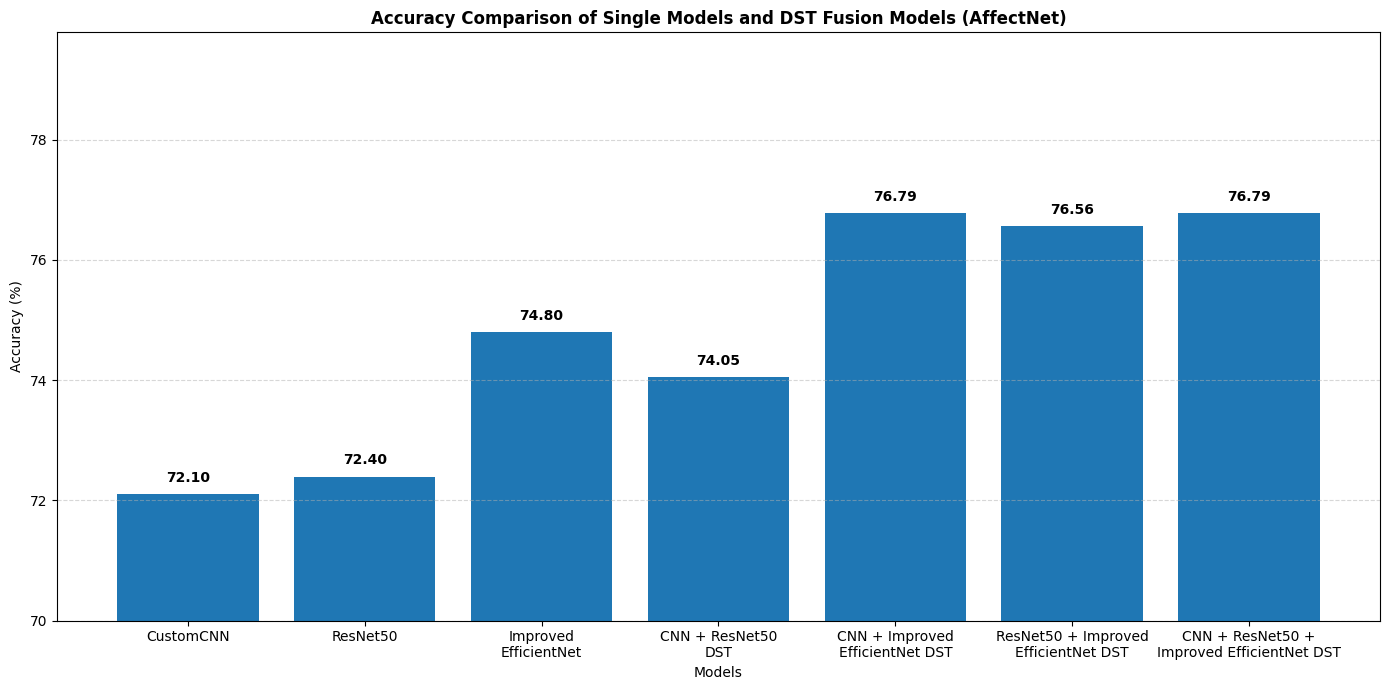

In [30]:
import matplotlib.pyplot as plt

# =========================
# Final model names and accuracies
# =========================
model_names = [
    "CustomCNN",
    "ResNet50",
    "Improved\nEfficientNet",
    "CNN + ResNet50\nDST",
    "CNN + Improved\nEfficientNet DST",
    "ResNet50 + Improved\nEfficientNet DST",
    "CNN + ResNet50 +\nImproved EfficientNet DST"
]

accuracies = [
    cnn_acc_affect,
    resnet_acc_affect,
    eff_acc_affect_v2,
    cnn_resnet_acc_affect_v2,
    cnn_eff_acc_affect_v2,
    resnet_eff_acc_affect_v2,
    cnn_resnet_eff_acc_affect_v2
]

# =========================
# Plot
# =========================
plt.figure(figsize=(14, 7))
bars = plt.bar(model_names, accuracies)

# add values on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.15,
        f"{acc:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Accuracy Comparison of Single Models and DST Fusion Models (AffectNet)", fontweight='bold')
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(70, max(accuracies) + 3)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

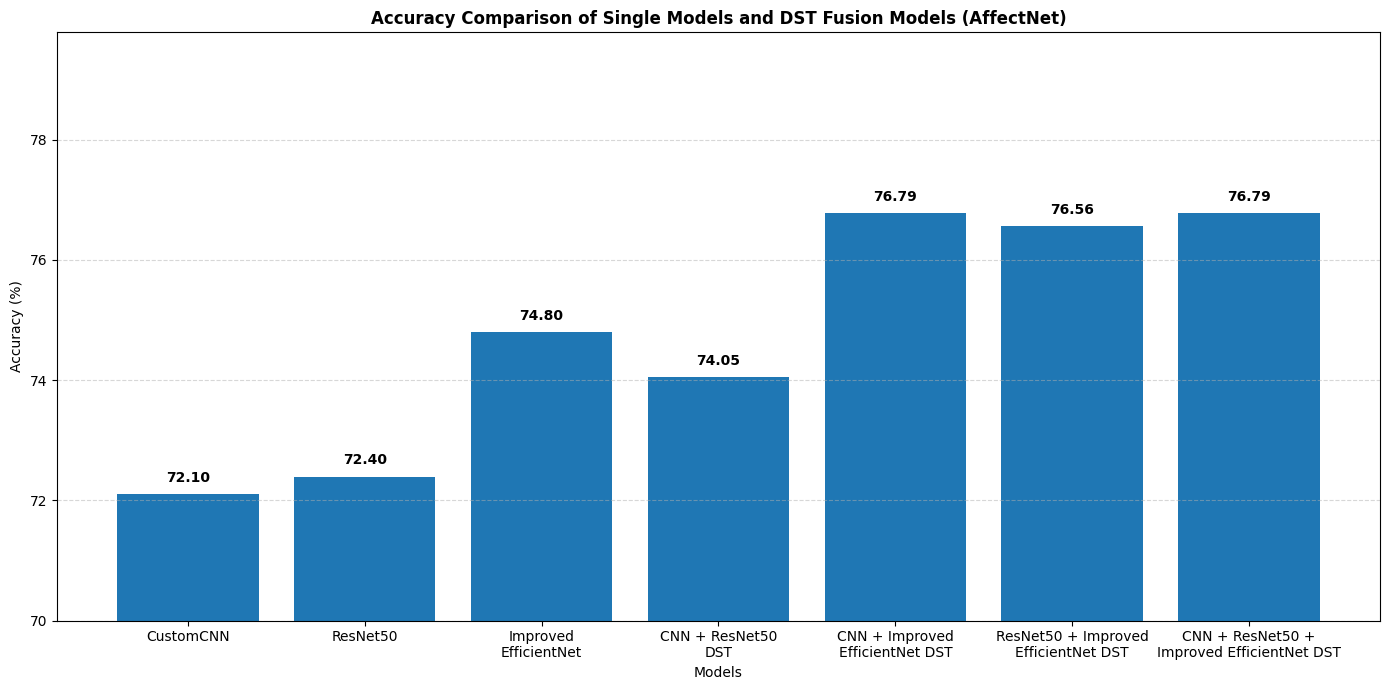

Saved chart at:
/kaggle/working/affectnet_accuracy_comparison.png


In [31]:
import matplotlib.pyplot as plt

# =========================
# Final model names and accuracies
# =========================
model_names = [
    "CustomCNN",
    "ResNet50",
    "Improved\nEfficientNet",
    "CNN + ResNet50\nDST",
    "CNN + Improved\nEfficientNet DST",
    "ResNet50 + Improved\nEfficientNet DST",
    "CNN + ResNet50 +\nImproved EfficientNet DST"
]

accuracies = [
    cnn_acc_affect,
    resnet_acc_affect,
    eff_acc_affect_v2,
    cnn_resnet_acc_affect_v2,
    cnn_eff_acc_affect_v2,
    resnet_eff_acc_affect_v2,
    cnn_resnet_eff_acc_affect_v2
]

# =========================
# Plot
# =========================
plt.figure(figsize=(14, 7))
bars = plt.bar(model_names, accuracies)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.15,
        f"{acc:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Accuracy Comparison of Single Models and DST Fusion Models (AffectNet)", fontweight='bold')
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(70, max(accuracies) + 3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# =========================
# Save chart
# =========================
save_path = "/kaggle/working/affectnet_accuracy_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart at:")
print(save_path)

Random Test Image Path: /kaggle/input/datasets/mstjebashazida/affectnet/archive (3)/Train/neutral/ffhq_3903.png
True Label: 5 - Neutral


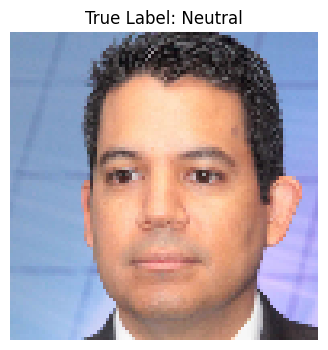

In [32]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# AffectNet class names
class_names_affect = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# pick random test image
random_idx = random.randint(0, len(test_df_affect) - 1)

img_path = test_df_affect.iloc[random_idx]["image_path"]
true_label_idx = int(test_df_affect.iloc[random_idx]["label"])
true_label_name = class_names_affect[true_label_idx]

print("Random Test Image Path:", img_path)
print("True Label:", true_label_idx, "-", true_label_name)

# show image
img = Image.open(img_path).convert("RGB")
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"True Label: {true_label_name}")
plt.axis("off")
plt.show()

In [33]:
import torch

# prepare model inputs for the same selected image
cnn_input = cnn_test_transform_affect(img).unsqueeze(0).to(device)
resnet_input = resnet_test_transform_affect(img).unsqueeze(0).to(device)
eff_input = eff_test_transform_affect_v2(img).unsqueeze(0).to(device)

print("CNN input shape               :", cnn_input.shape)
print("ResNet50 input shape          :", resnet_input.shape)
print("Improved EfficientNet shape   :", eff_input.shape)

CNN input shape               : torch.Size([1, 3, 96, 96])
ResNet50 input shape          : torch.Size([1, 3, 96, 96])
Improved EfficientNet shape   : torch.Size([1, 3, 224, 224])


Random Test Image Path: /kaggle/input/datasets/mstjebashazida/affectnet/archive (3)/Train/neutral/ffhq_3903.png


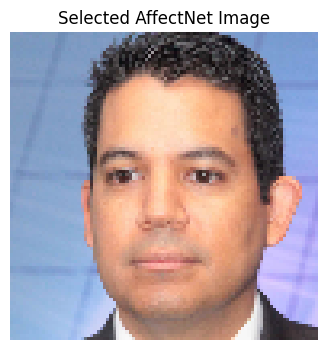

CNN input shape               : torch.Size([1, 3, 96, 96])
ResNet50 input shape          : torch.Size([1, 3, 96, 96])
Improved EfficientNet shape   : torch.Size([1, 3, 224, 224])

CNN probabilities shape              : (8,)
ResNet50 probabilities shape         : (8,)
Improved EfficientNet probabilities  : (8,)

CNN Prediction                           : Neutral
ResNet50 Prediction                      : Neutral
Improved EfficientNet Prediction         : Neutral
CNN + ResNet50 DST Prediction            : Neutral
CNN + EfficientNet DST Prediction        : Neutral
ResNet50 + EfficientNet DST Prediction   : Neutral
CNN + ResNet50 + EfficientNet Prediction : Neutral

Full Probability Table for Selected Image:

    Emotion       CNN  ResNet50  EfficientNet  CNN+ResNet DST  CNN+EffNet DST  \
0     Anger  0.008198  0.013553      0.011437        0.000132        0.000111   
1  Contempt  0.019923  0.018755      0.010904        0.000444        0.000256   
2   Disgust  0.005476  0.013280      0.012

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F

# =========================================================
# Exact image path
# =========================================================
img_path = "/kaggle/input/datasets/mstjebashazida/affectnet/archive (3)/Train/neutral/ffhq_3903.png"

class_names_affect = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

print("Random Test Image Path:", img_path)

# =========================================================
# Load image
# =========================================================
img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title("Selected AffectNet Image")
plt.axis("off")
plt.show()

# =========================================================
# Prepare inputs
# =========================================================
cnn_input = cnn_test_transform_affect(img).unsqueeze(0).to(device)
resnet_input = resnet_test_transform_affect(img).unsqueeze(0).to(device)
eff_input = eff_test_transform_affect_v2(img).unsqueeze(0).to(device)

print("CNN input shape               :", cnn_input.shape)
print("ResNet50 input shape          :", resnet_input.shape)
print("Improved EfficientNet shape   :", eff_input.shape)

# =========================================================
# Eval mode
# =========================================================
cnn_model_affect.eval()
resnet_model_affect.eval()
efficientnet_model_affect_v2.eval()

# =========================================================
# Get single-model probabilities
# =========================================================
with torch.no_grad():
    cnn_probs_single = F.softmax(cnn_model_affect(cnn_input), dim=1).cpu().numpy().flatten()
    resnet_probs_single = F.softmax(resnet_model_affect(resnet_input), dim=1).cpu().numpy().flatten()
    eff_probs_single = F.softmax(efficientnet_model_affect_v2(eff_input), dim=1).cpu().numpy().flatten()

print("\nCNN probabilities shape              :", cnn_probs_single.shape)
print("ResNet50 probabilities shape         :", resnet_probs_single.shape)
print("Improved EfficientNet probabilities  :", eff_probs_single.shape)

# =========================================================
# DST helper functions
# =========================================================
def probs_to_mass(prob_vector):
    return prob_vector / np.sum(prob_vector)

def dst_combine_two(m1, m2, eps=1e-12):
    combined = m1 * m2
    s = combined.sum()
    if s < eps:
        combined = (m1 + m2) / 2.0
        return combined / combined.sum()
    return combined / s

# =========================================================
# DST probabilities
# =========================================================
cnn_resnet_dst = dst_combine_two(probs_to_mass(cnn_probs_single), probs_to_mass(resnet_probs_single))
cnn_eff_dst = dst_combine_two(probs_to_mass(cnn_probs_single), probs_to_mass(eff_probs_single))
resnet_eff_dst = dst_combine_two(probs_to_mass(resnet_probs_single), probs_to_mass(eff_probs_single))
cnn_resnet_eff_dst = dst_combine_two(probs_to_mass(cnn_resnet_dst), probs_to_mass(eff_probs_single))

# =========================================================
# Predictions
# =========================================================
cnn_pred = class_names_affect[np.argmax(cnn_probs_single)]
resnet_pred = class_names_affect[np.argmax(resnet_probs_single)]
eff_pred = class_names_affect[np.argmax(eff_probs_single)]
cnn_resnet_pred = class_names_affect[np.argmax(cnn_resnet_dst)]
cnn_eff_pred = class_names_affect[np.argmax(cnn_eff_dst)]
resnet_eff_pred = class_names_affect[np.argmax(resnet_eff_dst)]
cnn_resnet_eff_pred = class_names_affect[np.argmax(cnn_resnet_eff_dst)]

print("\nCNN Prediction                           :", cnn_pred)
print("ResNet50 Prediction                      :", resnet_pred)
print("Improved EfficientNet Prediction         :", eff_pred)
print("CNN + ResNet50 DST Prediction            :", cnn_resnet_pred)
print("CNN + EfficientNet DST Prediction        :", cnn_eff_pred)
print("ResNet50 + EfficientNet DST Prediction   :", resnet_eff_pred)
print("CNN + ResNet50 + EfficientNet Prediction :", cnn_resnet_eff_pred)

# =========================================================
# Full probability table
# =========================================================
softmax_df_all = pd.DataFrame({
    "Emotion": class_names_affect,
    "CNN": cnn_probs_single,
    "ResNet50": resnet_probs_single,
    "EfficientNet": eff_probs_single,
    "CNN+ResNet DST": cnn_resnet_dst,
    "CNN+EffNet DST": cnn_eff_dst,
    "ResNet+EffNet DST": resnet_eff_dst,
    "CNN+ResNet+EffNet DST": cnn_resnet_eff_dst
})

print("\nFull Probability Table for Selected Image:\n")
print(softmax_df_all.round(6))

In [ ]:
/kaggle/input/datasets/ankansamanta980/surprice-girl/surprice_img_g.jpeg

Random Test Image Path: /kaggle/input/datasets/ankansamanta980/surprice-girl/surprice_img_g.jpeg


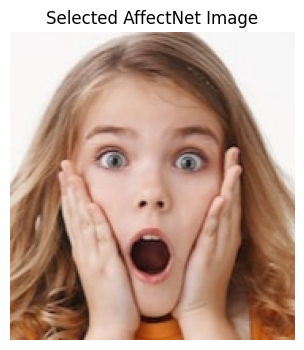

CNN input shape               : torch.Size([1, 3, 96, 96])
ResNet50 input shape          : torch.Size([1, 3, 96, 96])
Improved EfficientNet shape   : torch.Size([1, 3, 224, 224])

CNN probabilities shape              : (8,)
ResNet50 probabilities shape         : (8,)
Improved EfficientNet probabilities  : (8,)

CNN Prediction                           : Fear
ResNet50 Prediction                      : Surprise
Improved EfficientNet Prediction         : Surprise
CNN + ResNet50 DST Prediction            : Fear
CNN + EfficientNet DST Prediction        : Surprise
ResNet50 + EfficientNet DST Prediction   : Surprise
CNN + ResNet50 + EfficientNet Prediction : Surprise

Full Probability Table for Selected Image:

    Emotion       CNN  ResNet50  EfficientNet  CNN+ResNet DST  CNN+EffNet DST  \
0     Anger  0.002004  0.052399      0.022260        0.000248        0.000109   
1  Contempt  0.000115  0.011840      0.027285        0.000003        0.000008   
2   Disgust  0.001040  0.008767      0.0118

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F

# =========================================================
# Exact image path
# =========================================================
img_path = "/kaggle/input/datasets/ankansamanta980/surprice-girl/surprice_img_g.jpeg"

class_names_affect = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

print("Random Test Image Path:", img_path)

# =========================================================
# Load image
# =========================================================
img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title("Selected AffectNet Image")
plt.axis("off")
plt.show()

# =========================================================
# Prepare inputs
# =========================================================
cnn_input = cnn_test_transform_affect(img).unsqueeze(0).to(device)
resnet_input = resnet_test_transform_affect(img).unsqueeze(0).to(device)
eff_input = eff_test_transform_affect_v2(img).unsqueeze(0).to(device)

print("CNN input shape               :", cnn_input.shape)
print("ResNet50 input shape          :", resnet_input.shape)
print("Improved EfficientNet shape   :", eff_input.shape)

# =========================================================
# Eval mode
# =========================================================
cnn_model_affect.eval()
resnet_model_affect.eval()
efficientnet_model_affect_v2.eval()

# =========================================================
# Get single-model probabilities
# =========================================================
with torch.no_grad():
    cnn_probs_single = F.softmax(cnn_model_affect(cnn_input), dim=1).cpu().numpy().flatten()
    resnet_probs_single = F.softmax(resnet_model_affect(resnet_input), dim=1).cpu().numpy().flatten()
    eff_probs_single = F.softmax(efficientnet_model_affect_v2(eff_input), dim=1).cpu().numpy().flatten()

print("\nCNN probabilities shape              :", cnn_probs_single.shape)
print("ResNet50 probabilities shape         :", resnet_probs_single.shape)
print("Improved EfficientNet probabilities  :", eff_probs_single.shape)

# =========================================================
# DST helper functions
# =========================================================
def probs_to_mass(prob_vector):
    return prob_vector / np.sum(prob_vector)

def dst_combine_two(m1, m2, eps=1e-12):
    combined = m1 * m2
    s = combined.sum()
    if s < eps:
        combined = (m1 + m2) / 2.0
        return combined / combined.sum()
    return combined / s

# =========================================================
# DST probabilities
# =========================================================
cnn_resnet_dst = dst_combine_two(probs_to_mass(cnn_probs_single), probs_to_mass(resnet_probs_single))
cnn_eff_dst = dst_combine_two(probs_to_mass(cnn_probs_single), probs_to_mass(eff_probs_single))
resnet_eff_dst = dst_combine_two(probs_to_mass(resnet_probs_single), probs_to_mass(eff_probs_single))
cnn_resnet_eff_dst = dst_combine_two(probs_to_mass(cnn_resnet_dst), probs_to_mass(eff_probs_single))

# =========================================================
# Predictions
# =========================================================
cnn_pred = class_names_affect[np.argmax(cnn_probs_single)]
resnet_pred = class_names_affect[np.argmax(resnet_probs_single)]
eff_pred = class_names_affect[np.argmax(eff_probs_single)]
cnn_resnet_pred = class_names_affect[np.argmax(cnn_resnet_dst)]
cnn_eff_pred = class_names_affect[np.argmax(cnn_eff_dst)]
resnet_eff_pred = class_names_affect[np.argmax(resnet_eff_dst)]
cnn_resnet_eff_pred = class_names_affect[np.argmax(cnn_resnet_eff_dst)]

print("\nCNN Prediction                           :", cnn_pred)
print("ResNet50 Prediction                      :", resnet_pred)
print("Improved EfficientNet Prediction         :", eff_pred)
print("CNN + ResNet50 DST Prediction            :", cnn_resnet_pred)
print("CNN + EfficientNet DST Prediction        :", cnn_eff_pred)
print("ResNet50 + EfficientNet DST Prediction   :", resnet_eff_pred)
print("CNN + ResNet50 + EfficientNet Prediction :", cnn_resnet_eff_pred)

# =========================================================
# Full probability table
# =========================================================
softmax_df_all = pd.DataFrame({
    "Emotion": class_names_affect,
    "CNN": cnn_probs_single,
    "ResNet50": resnet_probs_single,
    "EfficientNet": eff_probs_single,
    "CNN+ResNet DST": cnn_resnet_dst,
    "CNN+EffNet DST": cnn_eff_dst,
    "ResNet+EffNet DST": resnet_eff_dst,
    "CNN+ResNet+EffNet DST": cnn_resnet_eff_dst
})

print("\nFull Probability Table for Selected Image:\n")
print(softmax_df_all.round(6))

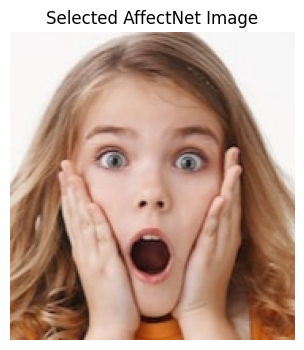

    Emotion       CNN  ResNet50  EfficientNet  DST Fusion
0  Surprise  0.396661  0.510755      0.603514    0.584637
1      Fear  0.599140  0.368776      0.283741    0.415174
2     Anger  0.002004  0.052399      0.022260    0.000109
3   Disgust  0.001040  0.008767      0.011857    0.000030
4     Happy  0.000330  0.025078      0.019735    0.000016
5       Sad  0.000465  0.011937      0.012490    0.000014
6   Neutral  0.000247  0.010448      0.019118    0.000012
7  Contempt  0.000115  0.011840      0.027285    0.000008

CNN Prediction       : Fear
ResNet50 Prediction  : Surprise
EfficientNet Prediction: Surprise
DST Prediction       : Surprise


In [40]:
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# =========================================================
# Exact image path
# =========================================================
img_path = "/kaggle/input/datasets/ankansamanta980/surprice-girl/surprice_img_g.jpeg"

class_names_affect = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================================================
# Load image
# =========================================================
img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title("Selected AffectNet Image")
plt.axis("off")
plt.show()

# =========================================================
# Prepare inputs
# =========================================================
cnn_input = cnn_test_transform_affect(img).unsqueeze(0).to(device)
resnet_input = resnet_test_transform_affect(img).unsqueeze(0).to(device)
eff_input = eff_test_transform_affect_v2(img).unsqueeze(0).to(device)

# =========================================================
# Eval mode
# =========================================================
cnn_model_affect.eval()
resnet_model_affect.eval()
efficientnet_model_affect_v2.eval()

# =========================================================
# Get single-model probabilities
# =========================================================
with torch.no_grad():
    cnn_probs_single = F.softmax(cnn_model_affect(cnn_input), dim=1).cpu().numpy().flatten()
    resnet_probs_single = F.softmax(resnet_model_affect(resnet_input), dim=1).cpu().numpy().flatten()
    eff_probs_single = F.softmax(efficientnet_model_affect_v2(eff_input), dim=1).cpu().numpy().flatten()

# =========================================================
# DST helper
# =========================================================
def probs_to_mass(prob_vector):
    return prob_vector / np.sum(prob_vector)

def dst_combine_two(m1, m2, eps=1e-12):
    combined = m1 * m2
    s = combined.sum()
    if s < eps:
        combined = (m1 + m2) / 2.0
        return combined / combined.sum()
    return combined / s

# =========================================================
# Best pair DST = CNN + Improved EfficientNet
# =========================================================
dst_probs = dst_combine_two(
    probs_to_mass(cnn_probs_single),
    probs_to_mass(eff_probs_single)
)

# =========================================================
# Build compact table
# =========================================================
softmax_df = pd.DataFrame({
    "Emotion": class_names_affect,
    "CNN": cnn_probs_single,
    "ResNet50": resnet_probs_single,
    "EfficientNet": eff_probs_single,
    "DST Fusion": dst_probs
})

# sort by DST fusion descending like a clean result table
softmax_df = softmax_df.sort_values(by="DST Fusion", ascending=False).reset_index(drop=True)

print(softmax_df.round(6))
print()

# =========================================================
# Predictions
# =========================================================
cnn_pred = class_names_affect[np.argmax(cnn_probs_single)]
resnet_pred = class_names_affect[np.argmax(resnet_probs_single)]
eff_pred = class_names_affect[np.argmax(eff_probs_single)]
dst_pred = class_names_affect[np.argmax(dst_probs)]

print("CNN Prediction       :", cnn_pred)
print("ResNet50 Prediction  :", resnet_pred)
print("EfficientNet Prediction:", eff_pred)
print("DST Prediction       :", dst_pred)

In [41]:
import pandas as pd

# =========================================================
# Final summary table for AffectNet
# =========================================================
final_summary_affect = pd.DataFrame({
    "Category": [
        "Single Model",
        "Single Model",
        "Single Model",
        "DST Fusion",
        "DST Fusion",
        "DST Fusion",
        "DST Fusion"
    ],
    "Model": [
        "CustomCNN",
        "ResNet50",
        "Improved EfficientNet",
        "CustomCNN + ResNet50",
        "CustomCNN + Improved EfficientNet",
        "ResNet50 + Improved EfficientNet",
        "CustomCNN + ResNet50 + Improved EfficientNet"
    ],
    "Accuracy (%)": [
        cnn_acc_affect,
        resnet_acc_affect,
        eff_acc_affect_v2,
        cnn_resnet_acc_affect_v2,
        cnn_eff_acc_affect_v2,
        resnet_eff_acc_affect_v2,
        cnn_resnet_eff_acc_affect_v2
    ]
})

final_summary_affect = final_summary_affect.sort_values(
    by="Accuracy (%)", ascending=False
).reset_index(drop=True)

print("Final AffectNet Summary Table:\n")
print(final_summary_affect)

print("\nBest Final Model on AffectNet:")
print(f"CustomCNN + Improved EfficientNet DST --> {cnn_eff_acc_affect_v2:.2f}% accuracy")

Final AffectNet Summary Table:

       Category                                         Model  Accuracy (%)
0    DST Fusion             CustomCNN + Improved EfficientNet     76.787463
1    DST Fusion  CustomCNN + ResNet50 + Improved EfficientNet     76.787463
2    DST Fusion              ResNet50 + Improved EfficientNet     76.558929
3  Single Model                         Improved EfficientNet     74.795952
4    DST Fusion                          CustomCNN + ResNet50     74.045054
5  Single Model                                      ResNet50     72.396343
6  Single Model                                     CustomCNN     72.102514

Best Final Model on AffectNet:
CustomCNN + Improved EfficientNet DST --> 76.79% accuracy
